In [7]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt

# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 1337

root_dir = Path("chest_xray")
train_dir = root_dir / "train"           # NORMAL / PNEUMONIA(/bacteria,virus)
test_dir  = root_dir / "test"            # NORMAL / PNEUMONIA(/bacteria,virus)
train_pneu_dir = train_dir / "PNEUMONIA" # bacteria / virus
test_pneu_dir  = test_dir / "PNEUMONIA"  # bacteria / virus

AUTOTUNE = tf.data.AUTOTUNE

In [8]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [9]:
# ====================================================
# 3. Task A1: NORMAL vs PNEUMONIA
#    - use train/ (NORMAL, PNEUMONIA)
#    - test/ as fixed test set
#    - 10% of train used as validation
# ====================================================
# Load full training (unbatched) and test
train_full_A1 = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A1 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A1 classes:", train_full_A1.class_names)  # ['NORMAL', 'PNEUMONIA']

total_train_A1 = train_full_A1.cardinality().numpy()
val_size_A1 = int(0.10 * total_train_A1)
train_size_A1 = total_train_A1 - val_size_A1

train_raw_A1 = train_full_A1.take(train_size_A1)
val_raw_A1   = train_full_A1.skip(train_size_A1)

# --- A1 subsets ---
total_train_A1 = train_raw_A1.cardinality().numpy()

def make_A1_subset(fraction):
    n = int(total_train_A1 * fraction)
    subset_raw = train_raw_A1.take(n)
    return prepare(subset_raw, shuffle=True)

train_A1_10  = make_A1_subset(0.10)
train_A1_25  = make_A1_subset(0.25)
train_A1_50  = make_A1_subset(0.50)
train_A1_100 = prepare(train_raw_A1, shuffle=True)  # full pool

val_A1 = prepare(val_raw_A1)
test_A1 = prepare(test_raw_A1)



Found 5232 files belonging to 2 classes.


2025-12-06 12:29:33.837836: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-06 12:29:33.938684: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:27:00.0, compute capability: 7.0


Found 624 files belonging to 2 classes.
A1 classes: ['NORMAL', 'PNEUMONIA']


In [10]:
# ====================================================
# 4. Task A2: BACTERIA vs VIRUS (pneumonia only)
#    - use train/PNEUMONIA (bacteria, virus)
#    - test/PNEUMONIA as fixed test
#    - 10% of pneumonia-train used as validation
# ====================================================
train_full_A2 = tf.keras.utils.image_dataset_from_directory(
    train_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A2 = tf.keras.utils.image_dataset_from_directory(
    test_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A2 classes:", train_full_A2.class_names)  # ['bacteria', 'virus']

total_train_A2 = train_full_A2.cardinality().numpy()
val_size_A2 = int(0.10 * total_train_A2)
train_size_A2 = total_train_A2 - val_size_A2

train_raw_A2 = train_full_A2.take(train_size_A2)
val_raw_A2   = train_full_A2.skip(train_size_A2)

# --- A2 subsets ---
total_train_A2 = train_raw_A2.cardinality().numpy()

def make_A2_subset(fraction):
    n = int(total_train_A2 * fraction)
    subset_raw = train_raw_A2.take(n)
    return prepare(subset_raw, shuffle=True)

train_A2_10  = make_A2_subset(0.10)
train_A2_25  = make_A2_subset(0.25)
train_A2_50  = make_A2_subset(0.50)
train_A2_100 = prepare(train_raw_A2, shuffle=True)

val_A2 = prepare(val_raw_A2, repeat=True)
test_A2 = prepare(test_raw_A2)

val_steps_A2 = max(1, val_raw_A2.cardinality().numpy() // BATCH_SIZE)




Found 3883 files belonging to 2 classes.
Found 390 files belonging to 2 classes.
A2 classes: ['bacteria', 'virus']


In [11]:
def make_backbone_B():
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",   
        pooling=None        
    )

def make_classifier_B(num_classes):
    backbone = make_backbone_B()
    backbone.trainable = False    

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)  

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)


    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [12]:
from collections import OrderedDict

# ====================================================
# 6B. Train Model B1 (NORMAL vs PNEUMONIA, Transfer Learning)
# ====================================================
EPOCHS = 20

b1_subsets = {
    "10%": train_A1_10,
    "25%": train_A1_25,
    "50%": train_A1_50,
    "100%": train_A1_100,
}

histories_B1 = {}
tests_B1 = {}
models_B1 = OrderedDict()

for name, train_ds in b1_subsets.items():
    print(f"\n=== B1 (Frozen MobileNetV2) training on {name} of pool ===")
    model = make_classifier_B(num_classes=2)   
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A1,
    )
    model.save_weights(f"B1_{name}.h5")   #I try to add this line because model C need to use the weights, but failed, my code works well last inght.
    histories_B1[name] = history.history
    tests_B1[name] = model.evaluate(test_A1, return_dict=True)
    models_B1[name] = model

print("B1 test metrics per subset:", tests_B1)



=== B1 (Frozen MobileNetV2) training on 10% of pool ===
Epoch 1/20


2025-12-06 12:29:40.312340: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2025-12-06 12:29:41.275491: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x55bd0a7c1f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-06 12:29:41.275517: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-12-06 12:29:41.281202: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-06 12:29:41.384012: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 [==============================] - 16s 748ms/step - loss: 0.6922 - accuracy: 0.6979 - val_loss: 0.4316 - val_accuracy: 0.7686
Epoch 2/20
15/15 [==============================] - 11s 637ms/step - loss: 0.4349 - accuracy: 0.7936 - val_loss: 0.3117 - val_accuracy: 0.8834
Epoch 3/20
15/15 [==============================] - 11s 628ms/step - loss: 0.3163 - accuracy: 0.8638 - val_loss: 0.2688 - val_accuracy: 0.8910
Epoch 4/20
15/15 [==============================] - 11s 632ms/step - loss: 0.2917 - accuracy: 0.8660 - val_loss: 0.2404 - val_accuracy: 0.9254
Epoch 5/20
15/15 [==============================] - 11s 640ms/step - loss: 0.2330 - accuracy: 0.9149 - val_loss: 0.2153 - val_accuracy: 0.9197
Epoch 6/20
15/15 [==============================] - 11s 629ms/step - loss: 0.2310 - accuracy: 0.9085 - val_loss: 0.2084 - val_accuracy: 0.9216
Epoch 7/20
15/15 [==============================] - 11s 640ms/step - loss: 0.2184 - accuracy: 0.9149 - val_loss: 0.1687 - val_accuracy: 0.9446
Epoch 8/20

In [13]:
# ====================================================
# 7B. Train Model B2 (BACTERIA vs VIRUS, Transfer Learning)
# ====================================================
b2_subsets = {
    "10%": train_A2_10,
    "25%": train_A2_25,
    "50%": train_A2_50,
    "100%": train_A2_100,
}

histories_B2 = {}
tests_B2 = {}
models_B2 = OrderedDict()  

for name, train_ds in b2_subsets.items():
    print(f"\n=== B2 (Frozen MobileNetV2) training on {name} of pool ===")
    model = make_classifier_B(num_classes=2)   
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A2,
        validation_steps=val_steps_A2,
    )
    model.save_weights(f"B2_{name}.h5")
    histories_B2[name] = history.history
    tests_B2[name] = model.evaluate(test_A2, return_dict=True)
    models_B2[name] = model           

print("B2 test metrics per subset:", tests_B2)



=== B2 (Frozen MobileNetV2) training on 10% of pool ===
Epoch 1/20
11/11 [==============================] - 8s 519ms/step - loss: 0.7316 - accuracy: 0.5874 - val_loss: 0.6736 - val_accuracy: 0.5833
Epoch 2/20
11/11 [==============================] - 5s 383ms/step - loss: 0.7070 - accuracy: 0.6218 - val_loss: 0.6168 - val_accuracy: 0.6380
Epoch 3/20
11/11 [==============================] - 5s 400ms/step - loss: 0.6663 - accuracy: 0.6447 - val_loss: 0.6047 - val_accuracy: 0.6693
Epoch 4/20
11/11 [==============================] - 6s 432ms/step - loss: 0.6470 - accuracy: 0.6877 - val_loss: 0.6177 - val_accuracy: 0.6745
Epoch 5/20
11/11 [==============================] - 5s 398ms/step - loss: 0.6214 - accuracy: 0.6791 - val_loss: 0.5203 - val_accuracy: 0.7604
Epoch 6/20
11/11 [==============================] - 5s 390ms/step - loss: 0.6021 - accuracy: 0.6991 - val_loss: 0.5551 - val_accuracy: 0.7500
Epoch 7/20
11/11 [==============================] - 5s 397ms/step - loss: 0.5787 - accuracy

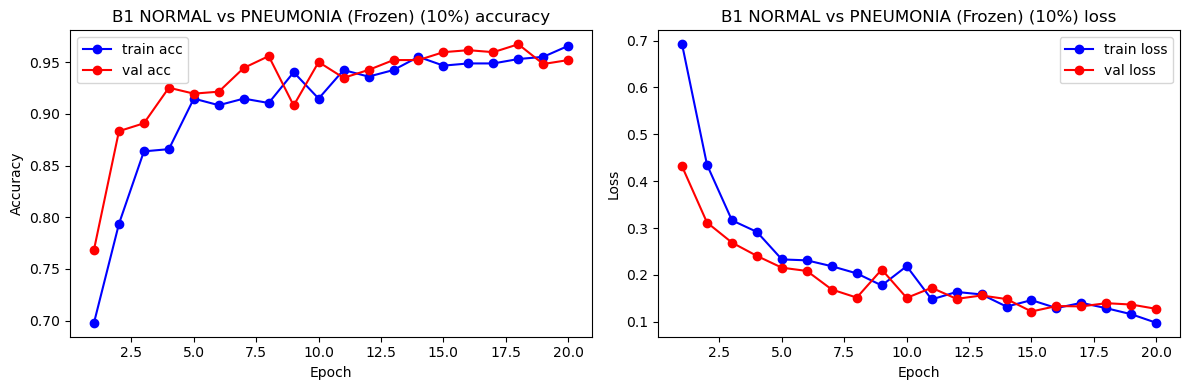

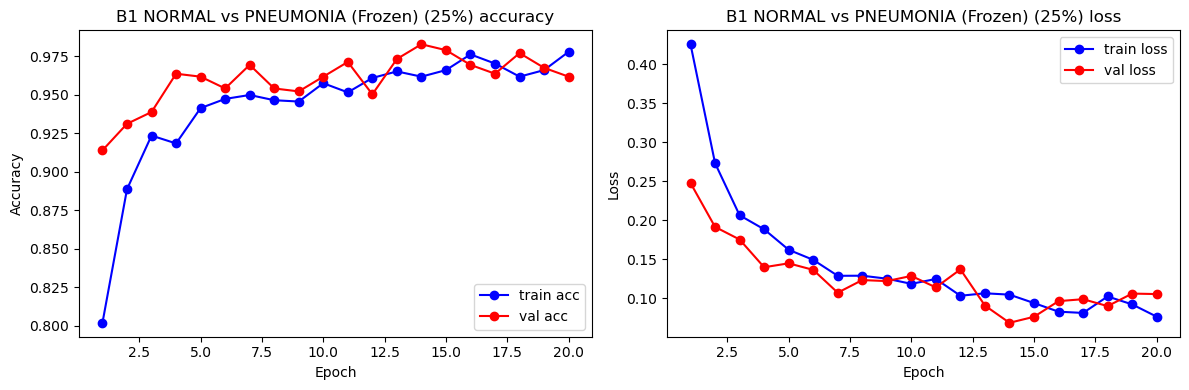

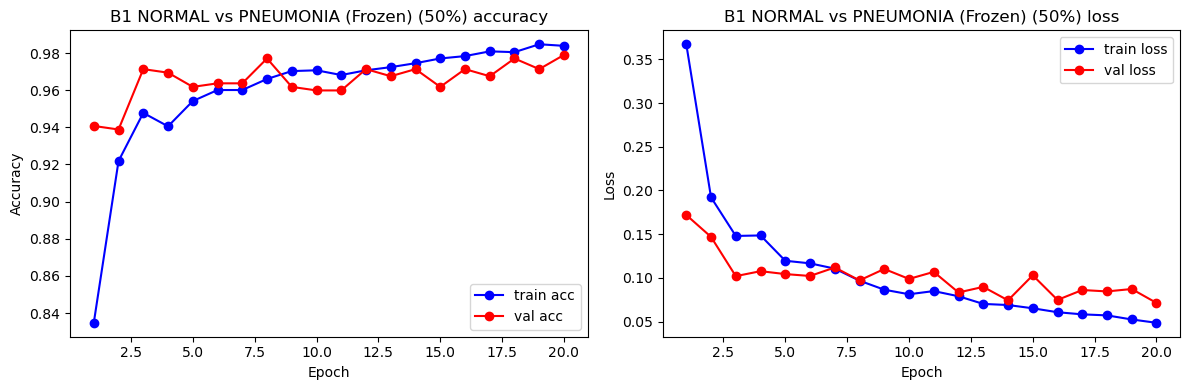

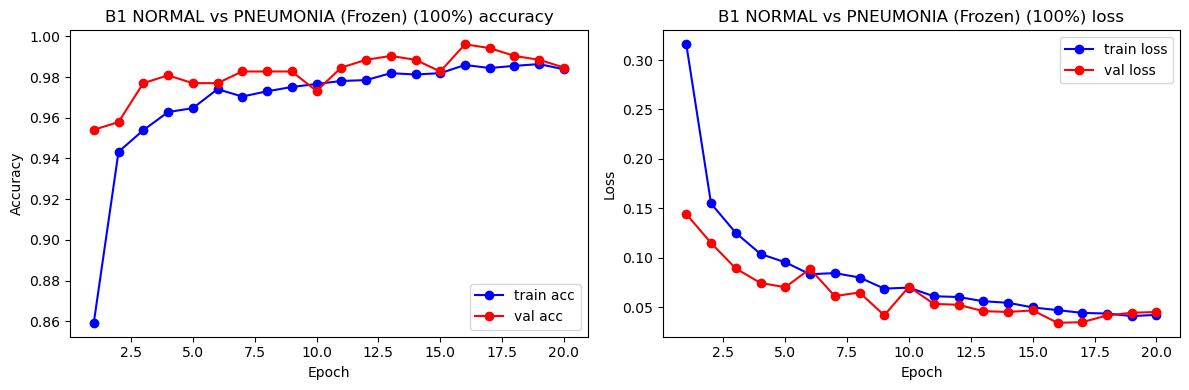

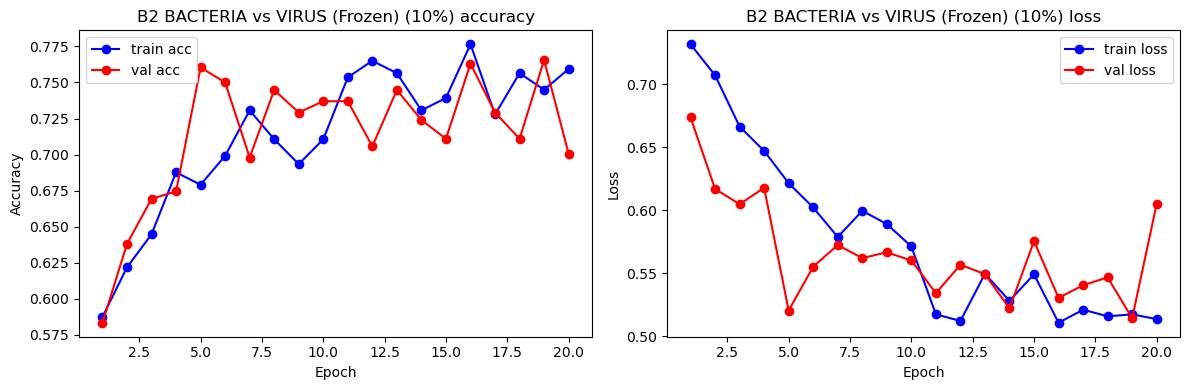

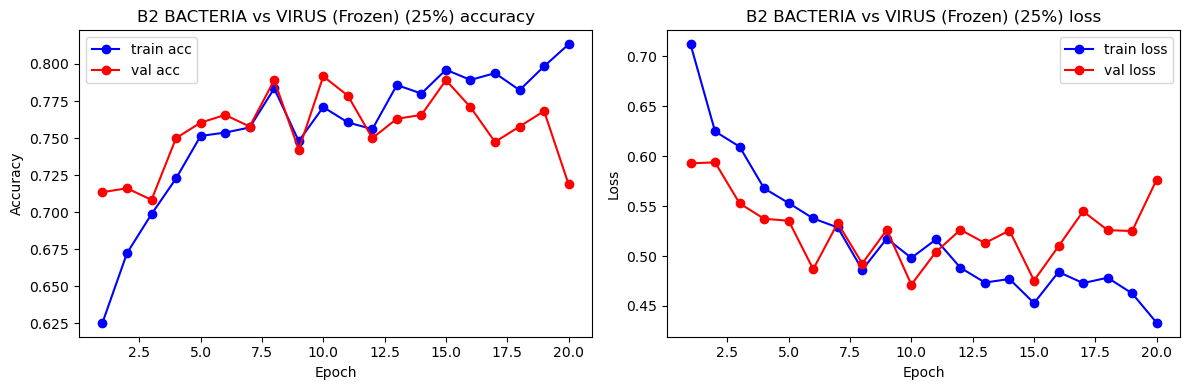

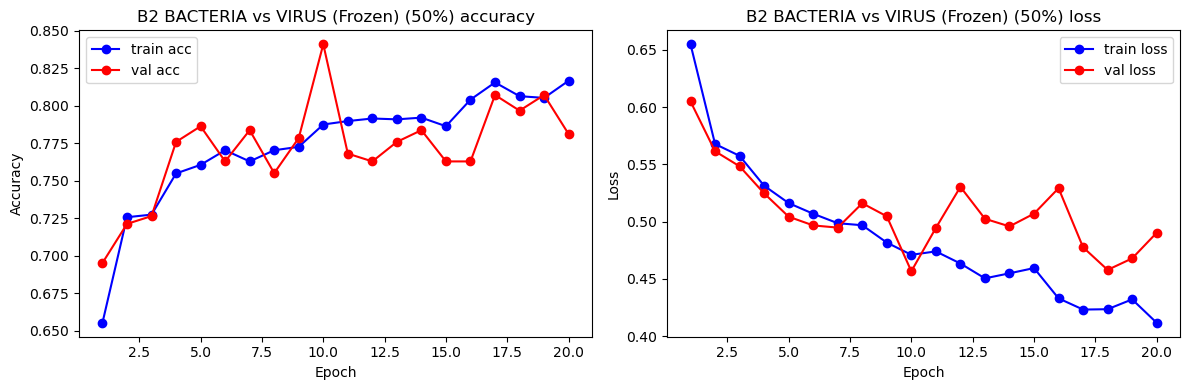

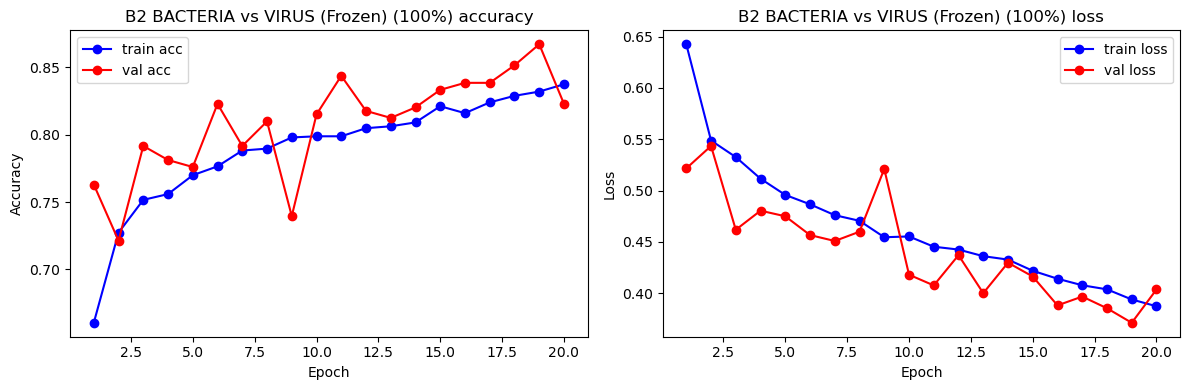

In [14]:
# ====================================================
# Plot histories for all subsets
# ====================================================

# small wrapper so plot_history can use .history like a Keras History object
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

# existing plotting function (unchanged)
def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if acc:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if val_acc:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if loss:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if val_loss:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ====================================================
# Plot B1 (Frozen MobileNetV2) histories
# ====================================================
for frac, hist_dict in histories_B1.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"B1 NORMAL vs PNEUMONIA (Frozen) ({frac})"
    )

# ====================================================
# Plot B2 (Frozen MobileNetV2) histories
# ====================================================
for frac, hist_dict in histories_B2.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"B2 BACTERIA vs VIRUS (Frozen) ({frac})"
    )


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def eval_with_confusion(model, test_ds, class_names, title="Model"):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        preds_labels = np.argmax(preds, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    print(f"\n{title} - Confusion matrix")
    print(cm)

    print(f"\n{title} - Classification report")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [16]:
class_names_A1 = ["NORMAL", "PNEUMONIA"]
class_names_A2 = ["BACTERIA", "VIRUS"]

# B1: NORMAL vs PNEUMONIA (Frozen Backbone)
for name, model in models_B1.items():
    eval_with_confusion(
        model,
        test_A1,
        class_names_A1,
        title=f"B1 Frozen ({name} train pool)"
    )

# B2: BACTERIA vs VIRUS (Frozen Backbone)
for name, model in models_B2.items():
    eval_with_confusion(
        model,
        test_A2,
        class_names_A2,
        title=f"B2 Frozen ({name} train pool)"
    )



B1 Frozen (10% train pool) - Confusion matrix
[[173  61]
 [  2 388]]

B1 Frozen (10% train pool) - Classification report
              precision    recall  f1-score   support

      NORMAL       0.99      0.74      0.85       234
   PNEUMONIA       0.86      0.99      0.92       390

    accuracy                           0.90       624
   macro avg       0.93      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624


B1 Frozen (25% train pool) - Confusion matrix
[[160  74]
 [  1 389]]

B1 Frozen (25% train pool) - Classification report
              precision    recall  f1-score   support

      NORMAL       0.99      0.68      0.81       234
   PNEUMONIA       0.84      1.00      0.91       390

    accuracy                           0.88       624
   macro avg       0.92      0.84      0.86       624
weighted avg       0.90      0.88      0.87       624


B1 Frozen (50% train pool) - Confusion matrix
[[181  53]
 [  2 388]]

B1 Frozen (50% train pool) - Cl